<a href="https://colab.research.google.com/github/tomkart/traffic_cam_nsw/blob/main/traffic_cameras_nsw_by_keyword.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install Pillow

In [ ]:
import requests
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

from PIL import Image
import io
import numpy as np # Import numpy for array operations
import math # Import math for ceiling function
import os


In [ ]:
from google.colab import userdata
API_KEY = userdata.get('NSW_API_KEY')


In [ ]:
# API endpoint and headers
API_URL = "https://api.transport.nsw.gov.au/v1/live/cameras"

# Updated headers to mimic Safari browser
image_url_headers = {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36",
    "Accept": "image/avif,image/webp,image/apng,image/*,*/*;q=0.8",
    "Referer": "https://webcams.transport.nsw.gov.au/",
}

headers = {
    "accept": "application/json",
    "Authorization": f"apikey {API_KEY}"
}

# Fetch the live camera data
def get_traffic_camera_data():
    response = requests.get(API_URL, headers=headers)
    if response.status_code == 200:
        return response.json()
    else:
        print(f"Error {response.status_code}: {response.text}")
        return None

# Parse and display the traffic camera data
def display_camera_data(data):
    cameras = data.get("features", [])

    if not cameras:
        print("No camera data available.")
        return

    camera_list = []
    for camera in cameras:
        properties = camera["properties"]
        coordinates = camera["geometry"]["coordinates"]
        camera_list.append({
            "Title": properties.get("title", "N/A"),
            "Image URL": properties.get("href", "N/A"),
            "Latitude": coordinates[1],
            "Longitude": coordinates[0],
            "View": properties.get("direction", "Unknown")
        })

    df = pd.DataFrame(camera_list)
    display(HTML(df.to_html()))
    return df

def show_camera_images(df, num_images=5, images_per_row=4):
    """
    Displays traffic camera images in a grid.

    Args:
        df (pd.DataFrame): DataFrame containing camera data.
        num_images (int, optional): Maximum number of images to display. Defaults to 5.
        images_per_row (int, optional): Number of images to display per row. Defaults to 4.
    """
    num_rows = math.ceil(num_images / images_per_row)  # Calculate the number of rows needed

    fig, axes = plt.subplots(num_rows, images_per_row, figsize=(20, 5 * num_rows))  # Create subplots

    # Flatten axes if num_rows or images_per_row is 1 for compatibility
    if num_rows == 1 or images_per_row == 1:
        axes = axes.flatten()
    else:
        axes = axes.ravel() #making it a 1D array to easy access

    for i in range(num_images):
        if i >= len(df):
            break
        img_url = df.iloc[i]["Image URL"]
        title = df.iloc[i]["Title"]

        # Open the URL using Pillow and convert to numpy array
        response = requests.get(img_url, headers=image_url_headers)

        # Check if the request was successful
        if response.status_code != 200:
            print(f"Error loading image from {img_url}: Status code {response.status_code}")
            continue  # Skip to the next image

        # Check content type to see if is an image
        content_type = response.headers.get('content-type')
        if 'image' not in content_type:
            print(f"URL {img_url} does not appear to be an image. Content-Type: {content_type}")
            continue

        try:
            response.raw.decode_content = True  # Ensure correct decoding
            img = Image.open(io.BytesIO(response.content))
            img = np.array(img)  # Convert PIL Image to NumPy array
            axes[i].imshow(img)
            axes[i].axis("off")
            axes[i].set_title(title, fontsize=10)
        except (PIL.UnidentifiedImageError, OSError) as e:
            print(f"Error loading or decoding image from {img_url}: {e}")
            continue

    plt.tight_layout()  # Adjust subplot parameters for a tight layout
    plt.show()


In [ ]:
# Fetch and display camera data
camera_data = get_traffic_camera_data()

camera_df = display_camera_data(camera_data)


,Title,Image URL,Latitude,Longitude,View
0,5 Ways (Miranda),https://webcams.transport.nsw.gov.au/livetraffic-webcams/cameras/5_ways_miranda.jpeg,-34.029770,151.105330,W
1,Airport Drive (Mascot),https://webcams.transport.nsw.gov.au/livetraffic-webcams/cameras/airport_dr_mascot.jpeg,-33.933667,151.161891,E
2,Alison Road (Randwick),https://webcams.transport.nsw.gov.au/livetraffic-webcams/cameras/alison_road_randwick.jpeg,-33.906410,151.231220,N-W
3,Anzac Bridge (Eastbound),https://webcams.transport.nsw.gov.au/livetraffic-webcams/cameras/anzac_bridge_eastbound.jpeg,-33.867890,151.180220,E
4,Anzac Bridge (Westbound),https://webcams.transport.nsw.gov.au/livetraffic-webcams/cameras/anzac_bridge_westbound.jpeg,-33.869692,151.188029,W
5,Anzac Parade (Kensington),https://webcams.transport.nsw.gov.au/livetraffic-webcams/cameras/anzac_parade_kensington.jpeg,-33.907296,151.223699,N
6,Anzac Parade (Kingsford),https://webcams.transport.nsw.gov.au/livetraffic-webcams/cameras/anzac_parade_kingsford.jpeg,-33.923886,151.227638,S
7,Anzac Parade (Moore Park),https://webcams.transport.nsw.gov.au/livetraffic-webcams/cameras/anzac_parade_moore_park.jpeg,-33.895340,151.221510,S
8,Audley Road (Audley Weir),https://webcams.transport.nsw.gov.au/livetraffic-webcams/cameras/audley_road_audley_weir.jpeg,-34.073084,151.056689,E
9,Audley Weir (East),https://webcams.transport.nsw.gov.au/livetraffic-webcams/cameras/audley_weir_east.jpeg,-34.073578,151.057465,N-W


In [ ]:
# prompt: write another camera_image_url which return all the possible url with the keyword

import pandas as pd
def camera_image_url(df, keyword):
    """
    Finds all image URLs containing the keyword in the provided DataFrame.

    Args:
        df (pd.DataFrame): DataFrame containing camera data.
        keyword (str): The keyword to search for in camera titles.

    Returns:
        list: A list of image URLs that contain the keyword, or an empty list if none are found.
    """
    cam_rows = df[df["Title"].str.contains(keyword, case=False, na=False)]
    if not cam_rows.empty:
        return cam_rows["Image URL"].tolist()
    else:
        return []


In [ ]:
# prompt: write a function to ask for a keyword and display all the images

def search_and_display_images(df, keyword):
    image_urls = camera_image_url(df, keyword)

    if image_urls:
        print(f"Image URL for '{keyword}': {image_url}")
        print(f"Displaying images for '{keyword}'")
        show_camera_images(df[df["Image URL"].isin(image_urls)], len(image_urls))
    else:
        print(f"No camera found with '{keyword}' in the title.")


Enter a keyword to search for a traffic camera: anzac
Image URL for 'anzac': ['https://webcams.transport.nsw.gov.au/livetraffic-webcams/cameras/anzac_bridge_eastbound.jpeg', 'https://webcams.transport.nsw.gov.au/livetraffic-webcams/cameras/anzac_bridge_westbound.jpeg', 'https://webcams.transport.nsw.gov.au/livetraffic-webcams/cameras/west_tower_anzac_br_looking_east.jpeg']
Displaying images for 'anzac'


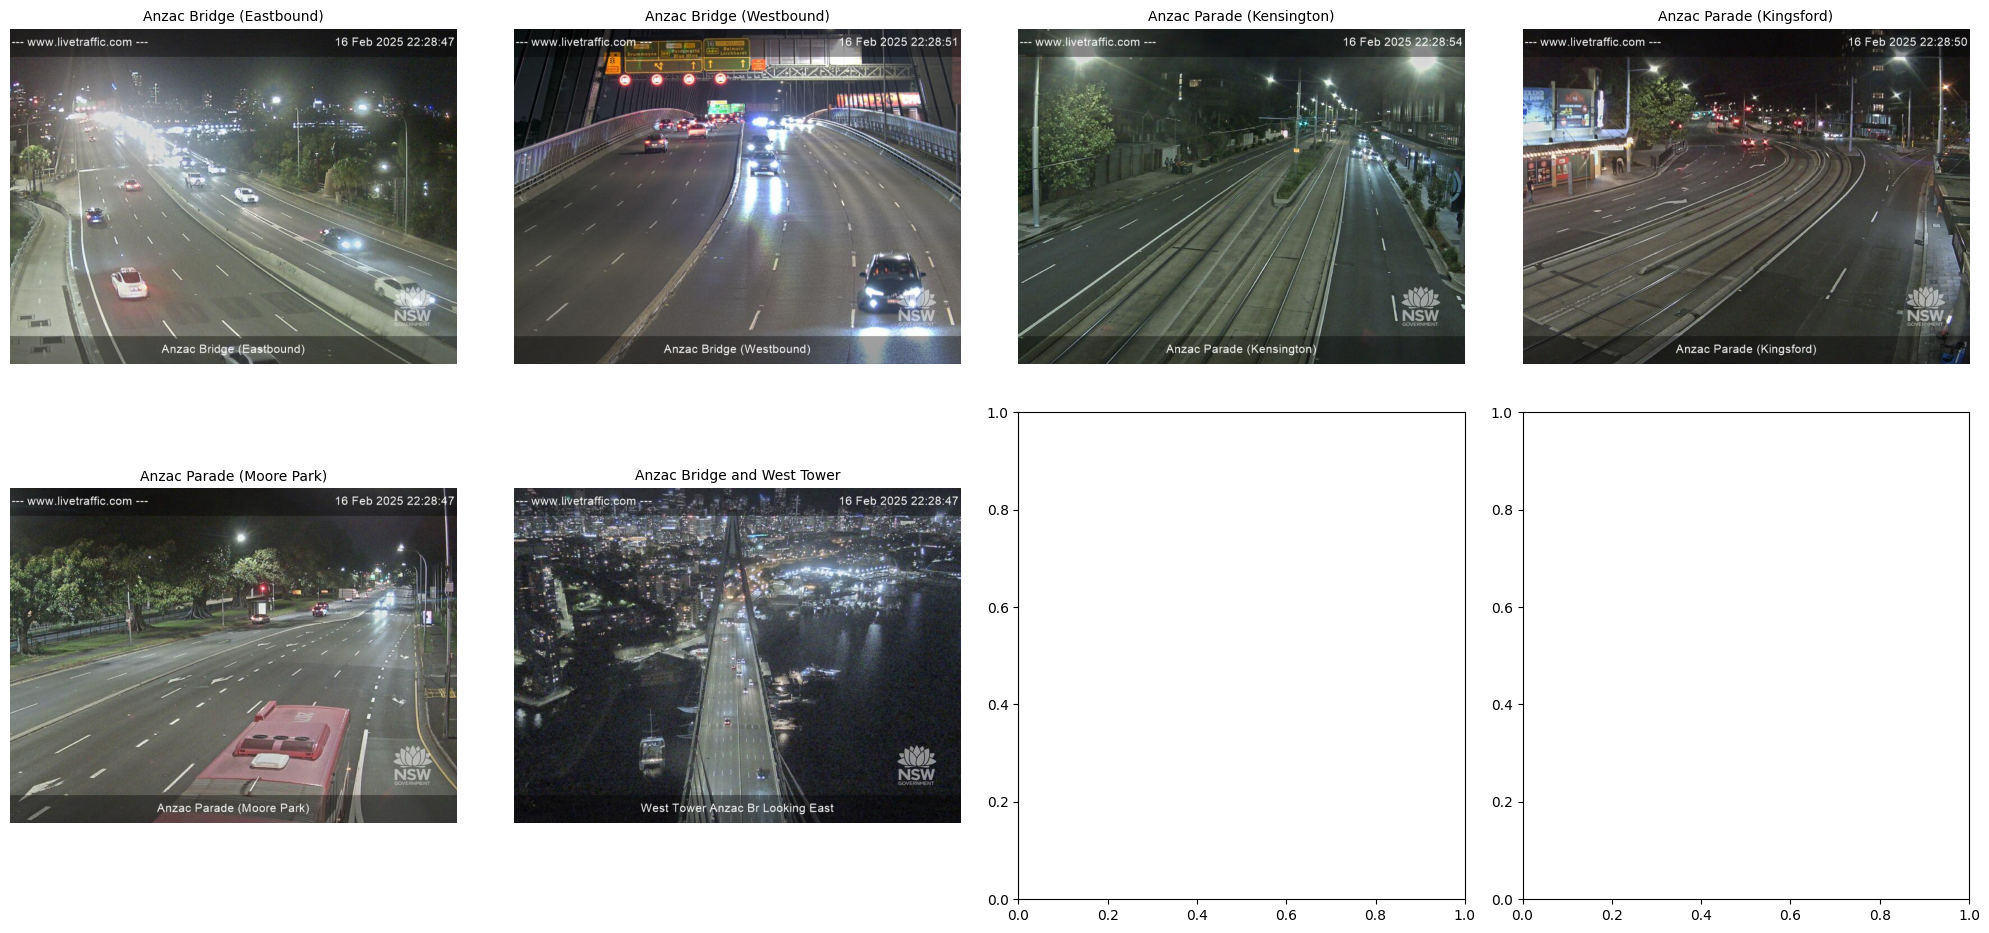

In [ ]:
"""
Asks for a keyword and displays images based on the keyword.
"""
keyword = input("Enter a keyword to search for a traffic camera: ")
# Call the function with your DataFrame
search_and_display_images(camera_df, keyword)

Image URL for 'bridge': ['https://webcams.transport.nsw.gov.au/livetraffic-webcams/cameras/anzac_bridge_eastbound.jpeg', 'https://webcams.transport.nsw.gov.au/livetraffic-webcams/cameras/anzac_bridge_westbound.jpeg', 'https://webcams.transport.nsw.gov.au/livetraffic-webcams/cameras/west_tower_anzac_br_looking_east.jpeg']
Displaying images for 'bridge'


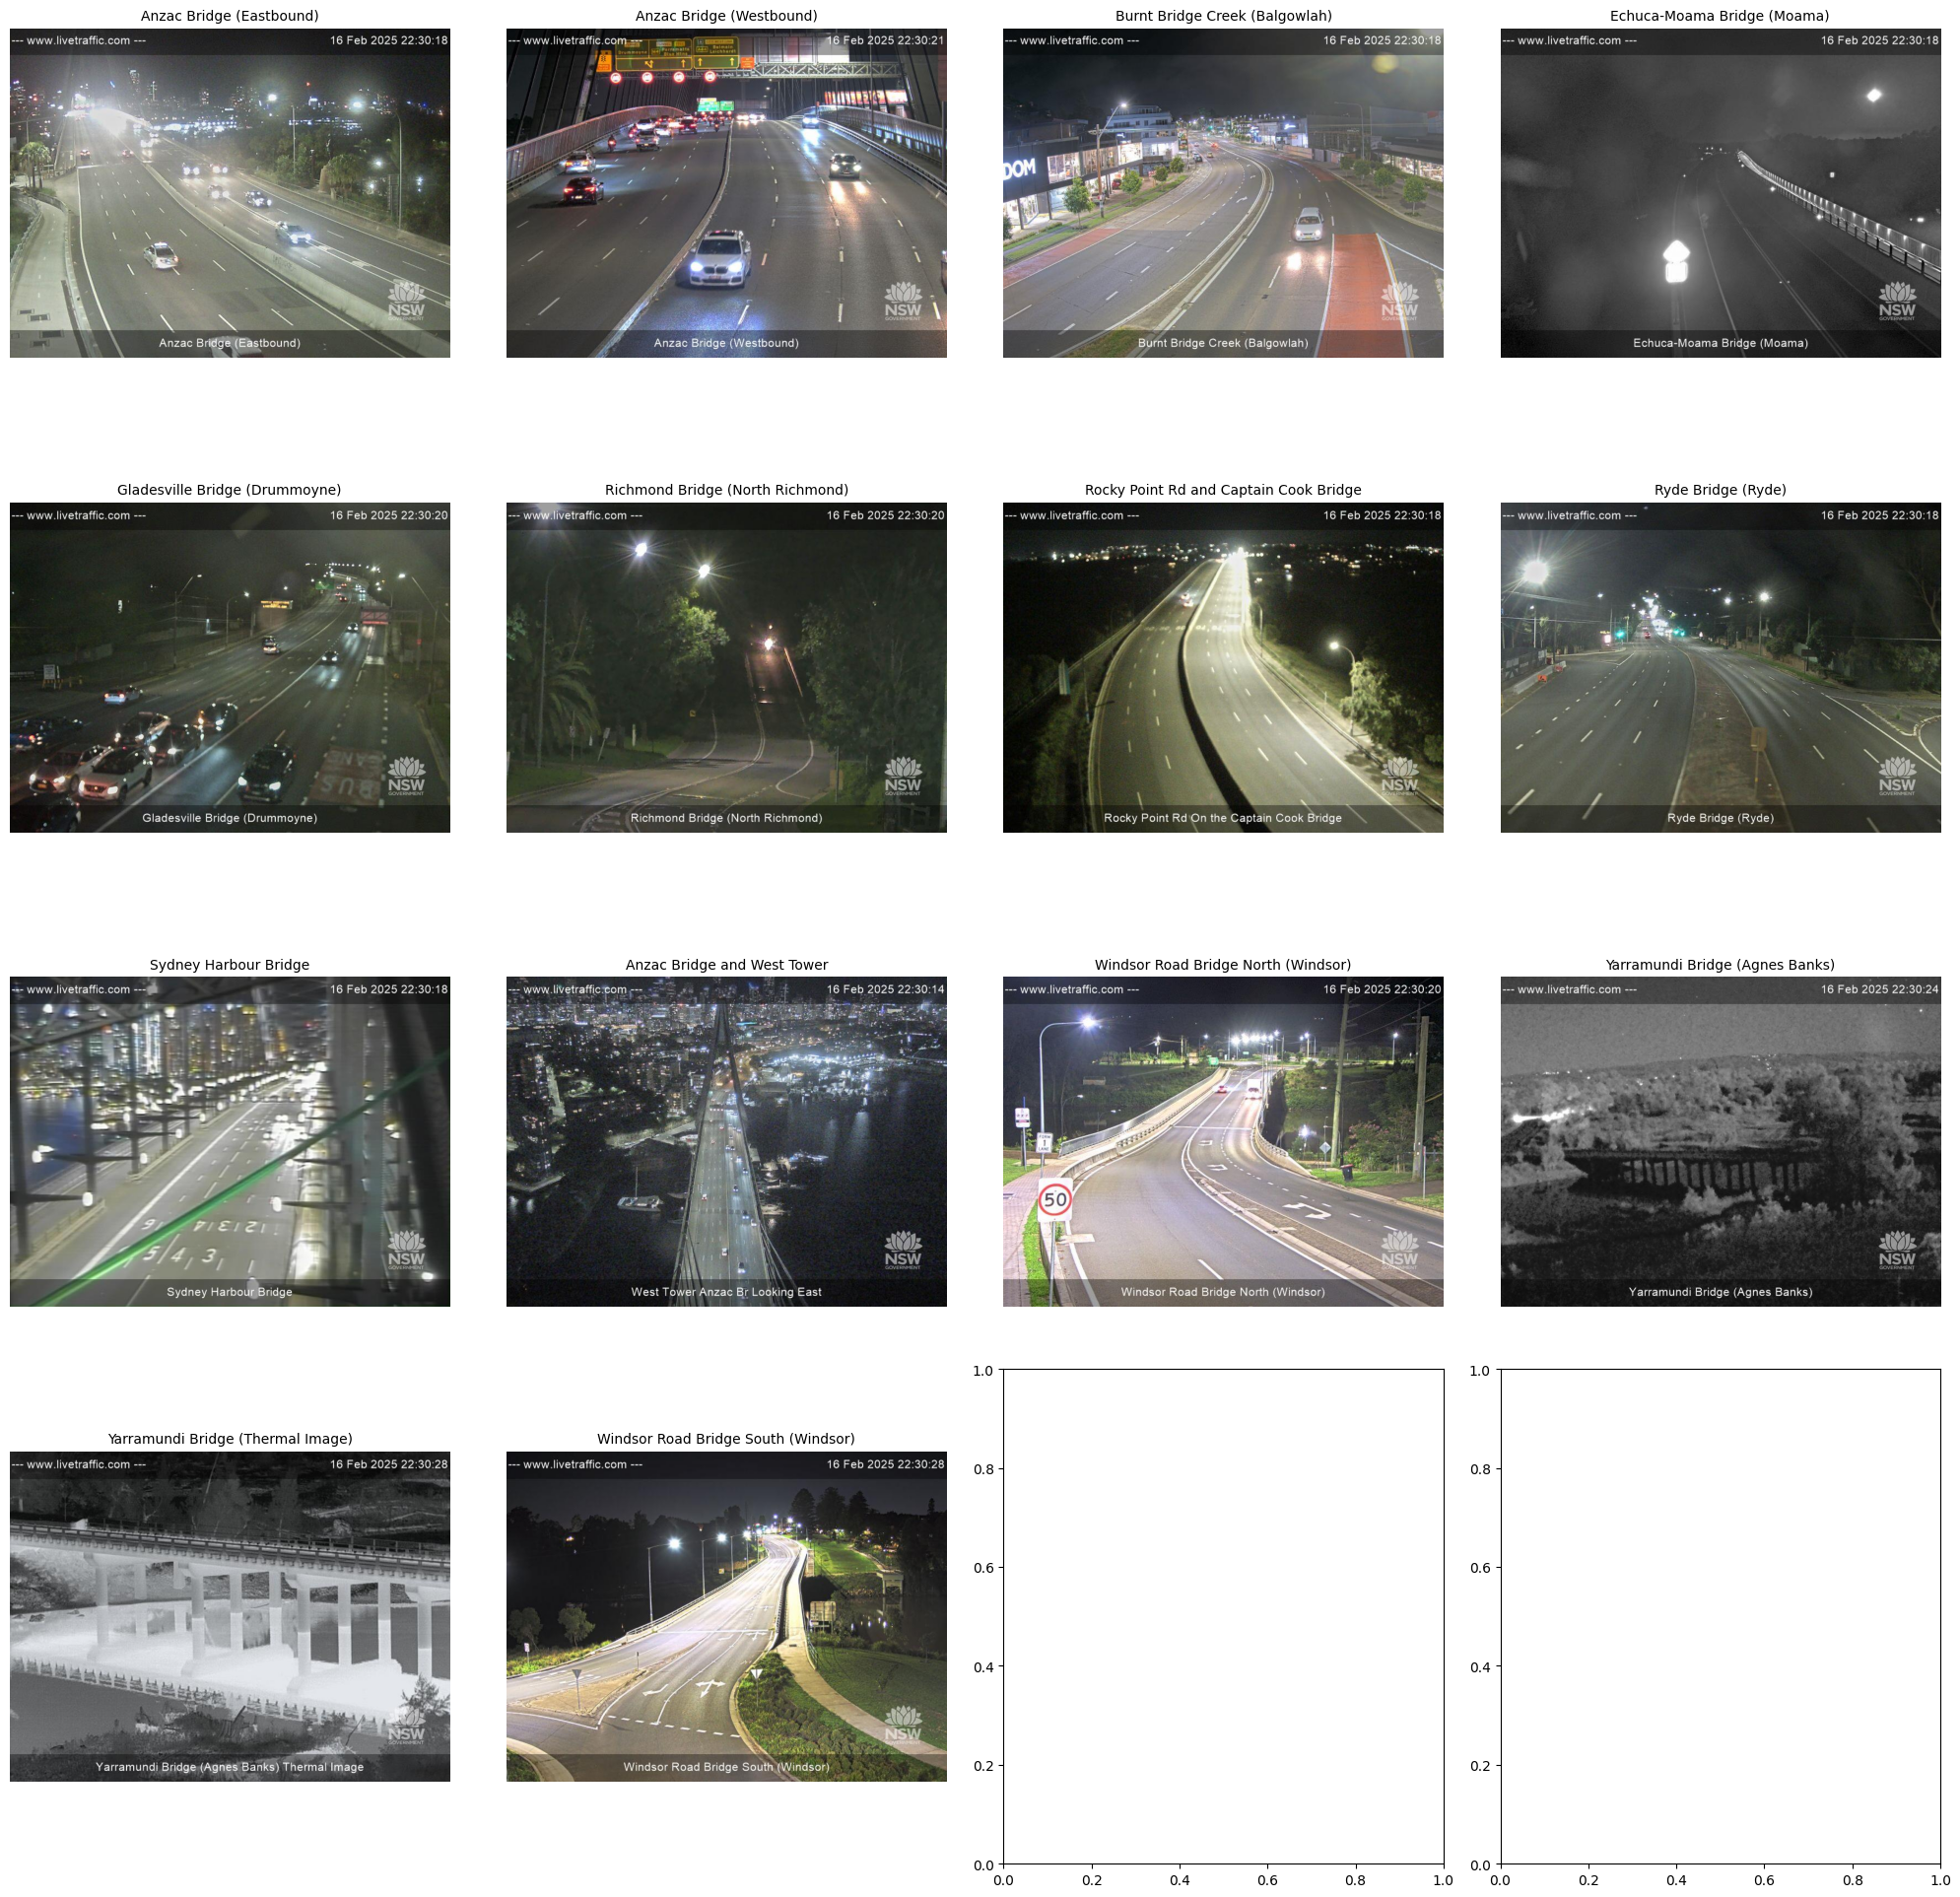

In [ ]:
search_and_display_images(camera_df, 'bridge')